In [1]:
# imports 
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder

from spd_learn.functional import bimap_transform, orthogonal_polar_factor
from spd_learn.functional import log_euclidean_geodesic
from spd_learn.modules    import ReEig, LogEig
from spd_learn.models     import SPDNet

from torch.nn.utils import parametrizations

import moabb
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from pyriemann.estimation import Covariances

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

Device : cuda


# ABiMap — Adaptive Dimension BiMap Layer

Standard SPDNet fixes the BiMap output dimension $m$ to $n \div 2$ — an arbitrary heuristic with no theoretical grounding.  
**ABiMap** learns $m$ jointly with the filter matrix during training.

**Key idea**

At any point during training, ABiMap maintains two consecutive BiMap outputs:
- $P_{lo}$ : projection with $m$ filters → SPD matrix of size $m \times m$
- $P_{hi}$ : projection with $m+1$ filters → SPD matrix of size $(m+1) \times (m+1)$

The output is interpolated along the **log-Euclidean geodesic**:

$$G(\alpha) = \exp\left((1-\alpha)\log \tilde{P}_{lo} + \alpha \log P_{hi}\right)$$

where $\alpha = \sigma(\beta / \tau)$ is learned by backpropagation.

In [ ]:
class ABiMap(nn.Module):
    """Adaptive-dimension BiMap layer (ABiMap).
    
    Args:
        n         : input SPD matrix dimension
        m_init    : initial output dimension
        m_max     : maximum output dimension (≤ n)
        tau       : sigmoid temperature (default 1.0)
        thresh_hi : expand threshold on alpha (default 0.95)
        thresh_lo : shrink threshold on alpha (default 0.05)
        verbose   : print transitions (default False)
    """

    def __init__(self, n, m_init, m_max, tau=1.0,
                 thresh_hi=0.95, thresh_lo=0.05, verbose=False):
        super().__init__()
        assert 1 <= m_init < m_max <= n

        self.n         = n
        self.m_max     = m_max
        self.tau       = tau
        self.thresh_hi = thresh_hi
        self.thresh_lo = thresh_lo
        self.verbose   = verbose
        self.m         = m_init

        self.beta = nn.Parameter(torch.tensor(0.0))
        self.W    = nn.Parameter(orthogonal_polar_factor(torch.randn(n, m_max)))
        parametrizations.orthogonal(module=self, name="W")

    # ── helpers ───────────────────────────────────────────────────────────────

    def _pad_spd(self, S, target_size):
        m   = S.shape[-1]
        q   = target_size - m
        out = torch.zeros(*S.shape[:-2], target_size, target_size, device=S.device, dtype=S.dtype)
        out[..., :m, :m] = S
        for i in range(q):
            out[..., m + i, m + i] = 1.0
        return out

    def _set_alpha(self, value):
        self.beta.data = torch.tensor(
            self.tau * np.log(value / (1 - value)),
            dtype=self.beta.dtype, device=self.beta.device
        )
    
    def _init_candidate_column(self):
        W_active = self.W.data[:, :self.m]
        w_cand   = torch.randn(self.n, device=self.W.device, dtype=self.W.dtype)
        w_cand   = w_cand - W_active @ (W_active.T @ w_cand)
        self.W.data[:, self.m] = w_cand / w_cand.norm()

    # ── dimension controller ──────────────────────────────────────────────────

    def _step(self):
        alpha = self.get_alpha()

        if alpha >= self.thresh_hi and self.m < self.m_max - 1:
            self.m += 1                    
            self._init_candidate_column()  
            self._set_alpha(0.1)
            if self.verbose:
                print(f"  [EXPAND] m → {self.m} | α = {self.get_alpha():.3f}")

        elif alpha <= self.thresh_lo and self.m > 1:
            self.m -= 1
            self._set_alpha(0.9)
            if self.verbose:
                print(f"  [SHRINK] m → {self.m} | α = {self.get_alpha():.3f}")

    # ── forward ───────────────────────────────────────────────────────────────

    def forward(self, X):
        if self.training:
            with torch.no_grad():
                self._step()

            alpha    = torch.sigmoid(self.beta / self.tau)
            m        = self.m
            S_lo     = bimap_transform(X, self.W[:, :m])
            S_hi     = bimap_transform(X, self.W[:, :m + 1])
            S_lo_pad = self._pad_spd(S_lo, m + 1)
            S_mix    = log_euclidean_geodesic(S_lo_pad, S_hi, alpha)
            return self._pad_spd(S_mix, self.m_max)

        else:
            m_f = self.get_final_m()
            S   = bimap_transform(X, self.W[:, :m_f])
            return self._pad_spd(S, self.m_max)

    # ── accessors ─────────────────────────────────────────────────────────────

    def get_alpha(self):   return torch.sigmoid(self.beta / self.tau).item()
    def get_m(self):       return self.m
    def get_final_m(self): return self.m + 1 if self.get_alpha() >= 0.5 else self.m

In [3]:
class ABiMapNet(nn.Module):
    """SPDNet with a single ABiMap layer.

    Args:
        n         : input SPD matrix dimension
        m_init    : initial output dimension of ABiMap
        m_max     : maximum output dimension (≤ n)
        n_classes : number of output classes
        **kwargs  : passed to ABiMap (tau, thresh_hi, thresh_lo, verbose)
    """

    def __init__(self, n, m_init, m_max, n_classes, **kwargs):
        super().__init__()
        self.bimap  = ABiMap(n=n, m_init=m_init, m_max=m_max, **kwargs)
        self.reeig  = ReEig()
        self.logeig = LogEig(flatten=True)
        self.fc     = nn.Linear(m_max * (m_max + 1) // 2, n_classes)

    def forward(self, X):
        return self.fc(self.logeig(self.reeig(self.bimap(X))))

    def get_alpha(self):   return self.bimap.get_alpha()
    def get_m(self):       return self.bimap.get_m()
    def get_final_m(self): return self.bimap.get_final_m()

**Training — Subject 1, BNCI2014-001 (4 classes)**
for this example : Training is on session 1 called "0train" and Test is on session 2 called "1test"

In [4]:
# ── Configuration ───────────────────────────────────────────────
SUBJECT    = 1
M_INIT     = 2
M_MAX      = 21
N_EPOCHS   = 3000
BATCH_SIZE = 128
CLASSES    = ['left_hand', 'right_hand', 'feet', 'tongue']

dataset  = BNCI2014_001()
paradigm = MotorImagery(events=CLASSES, n_classes=len(CLASSES), fmin=8, fmax=32)

# ── Data ──────────────────────────────────────────────────────────────────────
X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=[SUBJECT])

mask = meta['session'] == '0train'
X_tr_cov = Covariances(estimator='lwf').fit_transform(X_raw[mask])
y_tr     = LabelEncoder().fit_transform(y_raw[mask])

mask = meta['session'] == '1test'
X_te_cov = Covariances(estimator='lwf').fit_transform(X_raw[mask])
y_te     = LabelEncoder().fit_transform(y_raw[mask])

n_chans = X_tr_cov.shape[1]

X_train = torch.tensor(X_tr_cov, dtype=torch.float32).to(device)
y_train = torch.tensor(y_tr,     dtype=torch.long).to(device)
X_test  = torch.tensor(X_te_cov, dtype=torch.float32).to(device)
y_test  = torch.tensor(y_te,     dtype=torch.long).to(device)

print(f"Train / Test : {len(X_train)} / {len(X_test)}")

Train / Test : 288 / 288


In [5]:
# ── Model ─────────────────────────────────────────────────────────────────────
model = ABiMapNet(
    n=n_chans, m_init=M_INIT, m_max=M_MAX,
    n_classes=len(CLASSES), tau=0.5,
    thresh_hi=0.95, thresh_lo=0.05, verbose=True
).to(device)

optimizer = torch.optim.Adam([
    {'params': [model.bimap.parametrizations.W.original],       'lr': 1e-3}, 
    {'params': [model.bimap.beta],    'lr': 1e-2},
    {'params': model.fc.parameters(), 'lr': 1e-3},
])
criterion = nn.CrossEntropyLoss()


# ── Training ──────────────────────────────────────────────────────────────────
logs = []

for epoch in range(N_EPOCHS):
    # ── training  ── 
    model.train()
    optimizer.zero_grad()
    idx  = torch.randperm(len(X_train), device=device)[:BATCH_SIZE]
    loss = criterion(model(X_train[idx]), y_train[idx])
    loss.backward()
    optimizer.step()

    # ── Evaluation ── 
    model.eval()
    with torch.no_grad():
        acc_tr = (model(X_train).argmax(1) == y_train).float().mean().item()
        acc_te = (model(X_test).argmax(1)  == y_test ).float().mean().item()

    logs.append({
        'epoch'     : epoch,
        'train_loss': loss.item(),
        'acc_train' : acc_tr,
        'acc_test'  : acc_te,
        'alpha'     : model.get_alpha(),
        'm'         : model.get_m(),
    })

    if epoch % 100 == 0:
        print(f"  Epoch {epoch:5d} | loss={loss.item():.4f} | acc_tr={acc_tr:.3f} | "
              f"acc_test={acc_te:.3f} | m={model.get_m()} | alpha={model.get_alpha():.3f}")

# ── Final Evaluation ──────────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc_final = (model(X_test).argmax(1).cpu().numpy() == y_te).mean()

print(f"\n  m={model.get_m()} | m_final={model.get_final_m()} | "
      f"alpha={model.get_alpha():.3f} | acc_test={acc_final:.4f}")

  Epoch     0 | loss=1.4236 | acc_tr=0.253 | acc_test=0.278 | m=2 | alpha=0.495
  Epoch   100 | loss=1.3194 | acc_tr=0.580 | acc_test=0.608 | m=2 | alpha=0.777
  [EXPAND] m → 3 | α = 0.100
  Epoch   200 | loss=1.1861 | acc_tr=0.635 | acc_test=0.615 | m=3 | alpha=0.106
  Epoch   300 | loss=1.0997 | acc_tr=0.705 | acc_test=0.677 | m=3 | alpha=0.166
  Epoch   400 | loss=0.9704 | acc_tr=0.635 | acc_test=0.625 | m=3 | alpha=0.814
  [EXPAND] m → 4 | α = 0.100
  Epoch   500 | loss=0.9007 | acc_tr=0.719 | acc_test=0.691 | m=4 | alpha=0.115
  Epoch   600 | loss=0.7997 | acc_tr=0.705 | acc_test=0.670 | m=4 | alpha=0.175
  Epoch   700 | loss=0.7263 | acc_tr=0.757 | acc_test=0.726 | m=4 | alpha=0.700
  Epoch   800 | loss=0.6883 | acc_tr=0.774 | acc_test=0.740 | m=4 | alpha=0.943
  [EXPAND] m → 5 | α = 0.100
  Epoch   900 | loss=0.6403 | acc_tr=0.809 | acc_test=0.729 | m=5 | alpha=0.091
  Epoch  1000 | loss=0.6484 | acc_tr=0.806 | acc_test=0.705 | m=5 | alpha=0.107
  Epoch  1100 | loss=0.6128 | acc

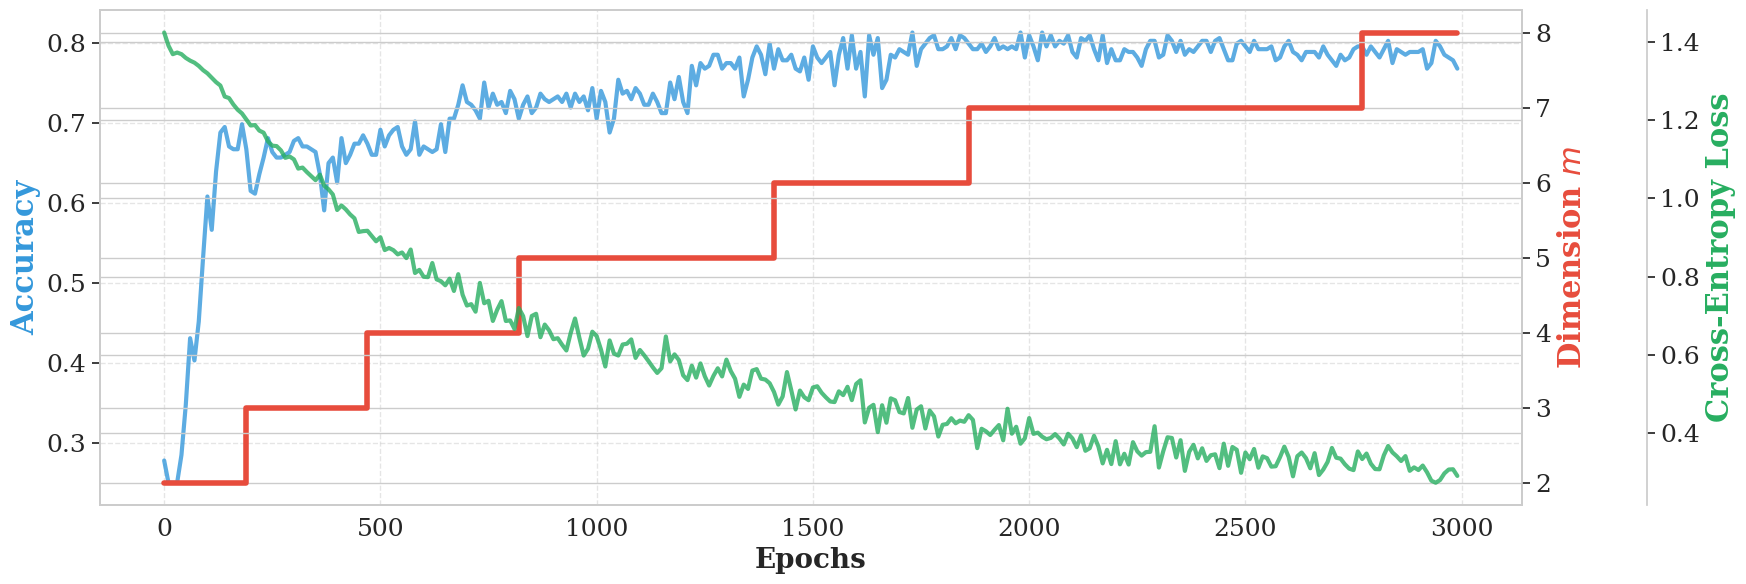

In [6]:
df = pd.DataFrame(logs)

def plot(df):
    fig, ax_acc = plt.subplots(1, 1, figsize=(18, 6))
    ax_m    = ax_acc.twinx()
    ax_loss = ax_acc.twinx()
    ax_loss.spines['right'].set_position(('outward', 90))

    step   = 10
    epochs = df['epoch'].values[::step]
    m      = df['m'].values[::step]
    acc    = df['acc_test'].values[::step]
    loss   = df['train_loss'].values[::step]

    ln2 = ax_acc.plot(epochs, acc,  color='#3498db', alpha=0.8, lw=3, label='Test Accuracy')
    ln1 = ax_m.step( epochs, m,     color='#e74c3c', lw=4, where='post', label='Dimension $m$')
    ln3 = ax_loss.plot(epochs, loss, color='#27ae60', alpha=0.8, lw=3, label='Train Loss')

    ax_acc.set_xlabel("Epochs",              fontsize=20, fontweight='bold')
    ax_acc.set_ylabel("Accuracy",            color='#3498db', fontsize=22, fontweight='bold')
    ax_m.set_ylabel("Dimension $m$",         color='#e74c3c', fontsize=22, fontweight='bold')
    ax_loss.set_ylabel("Cross-Entropy Loss", color='#27ae60', fontsize=22, fontweight='bold')

    ax_acc.tick_params(axis='both', labelsize=18)
    ax_m.tick_params(axis='y',     labelsize=18)
    ax_loss.tick_params(axis='y',  labelsize=18)
    ax_acc.grid(True, which='both', linestyle='--', alpha=0.5)


    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()

plot(df)

The model starts at $m=2$ and expands progressively for 3000 epochs. Each dimension expansion coincides with a jump in test accuracy, confirming that each
additional spatial filter captures genuinely discriminative information.

Here We train an SPDNet with a fixed m=11

In [7]:
# ── Configuration ───────────────────────────────────────────────
M = 11

# ── Model ─────────────────────────────────────────────────────────────────────
model     = SPDNet(input_type='cov', n_chans=X_tr_cov.shape[1],
                   subspacedim=M, n_outputs=len(CLASSES)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ── Training ──────────────────────────────────────────────────────────────────
logs_spdnet = []

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    idx  = torch.randperm(len(X_train), device=device)[:BATCH_SIZE]
    loss = criterion(model(X_train[idx]), y_train[idx])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        acc_tr = (model(X_train[idx]).argmax(1) == y_train[idx]).float().mean().item()
        acc_te = (model(X_test).argmax(1) == y_test).float().mean().item()

    logs_spdnet.append({
        'epoch'     : epoch,
        'train_loss': loss.item(),
        'acc_train' : acc_tr,
        'acc_test'  : acc_te,
    })

    if epoch % 500 == 0:
        print(f"  Epoch {epoch:5d} | loss={loss.item():.4f} | "
              f"acc_tr={acc_tr:.3f} | acc_test={acc_te:.3f}")

# ── Eval ──────────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc_final = (model(X_test).argmax(1).cpu().numpy() == y_te).mean()

print(f"\n  m={M} | acc_test={acc_final:.4f}")

  Epoch     0 | loss=1.6156 | acc_tr=0.242 | acc_test=0.250
  Epoch   500 | loss=0.6491 | acc_tr=0.867 | acc_test=0.778
  Epoch  1000 | loss=0.5237 | acc_tr=0.836 | acc_test=0.802
  Epoch  1500 | loss=0.4350 | acc_tr=0.867 | acc_test=0.799
  Epoch  2000 | loss=0.3665 | acc_tr=0.883 | acc_test=0.795
  Epoch  2500 | loss=0.3436 | acc_tr=0.883 | acc_test=0.799

  m=11 | acc_test=0.7847


**Comparing the results of the models**

In [8]:
df_abimap = pd.DataFrame(logs)
df_spdnet = pd.DataFrame(logs_spdnet)

acc_abimap = df_abimap['acc_test'].iloc[-1]
acc_spdnet = df_spdnet['acc_test'].iloc[-1]
m_final    = df_abimap['m'].iloc[-1]

print(f"  ABiMap  | m_final={m_final} | acc_test={acc_abimap:.4f}")
print(f"  SPDNet  | m={M}          | acc_test={acc_spdnet:.4f}")

  ABiMap  | m_final=8 | acc_test=0.7743
  SPDNet  | m=11          | acc_test=0.7847


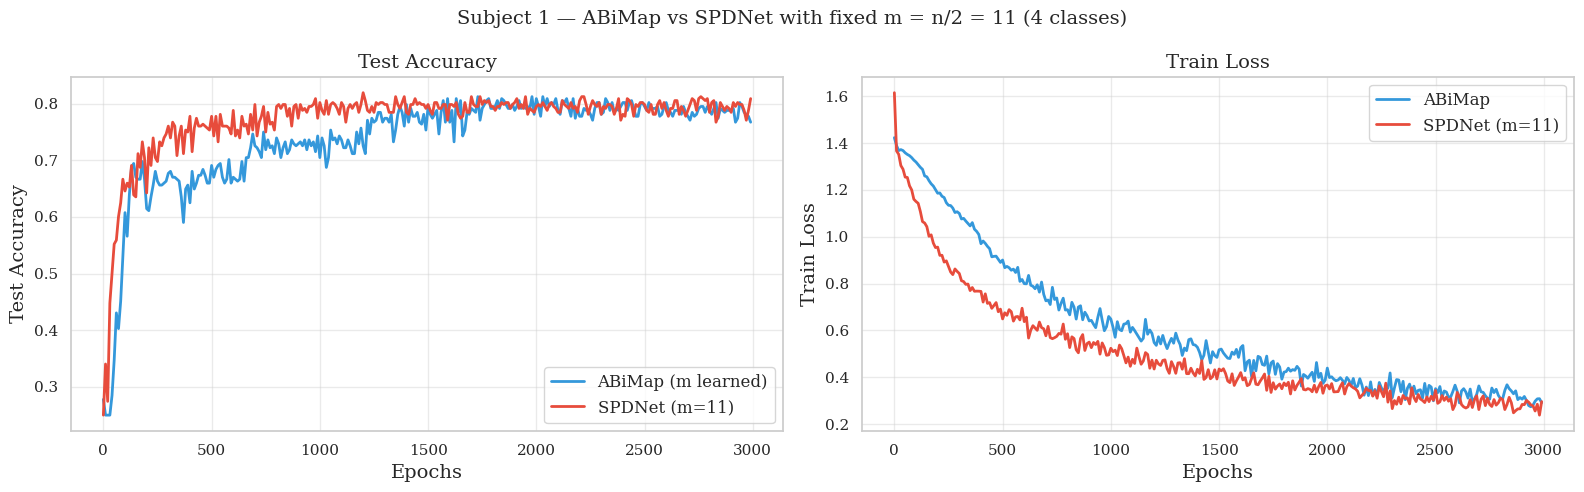

In [9]:
step = 10
df_a = df_abimap.iloc[::step]
df_s = df_spdnet.iloc[::step]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_a['epoch'], df_a['acc_test'], color='#3498db', lw=2, label='ABiMap (m learned)')
ax.plot(df_s['epoch'], df_s['acc_test'], color='#e74c3c', lw=2, label=f'SPDNet (m={M})')
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Test Accuracy', fontsize=14)
ax.set_title('Test Accuracy', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_a['epoch'], df_a['train_loss'], color='#3498db', lw=2, label='ABiMap')
ax.plot(df_s['epoch'], df_s['train_loss'], color='#e74c3c', lw=2, label=f'SPDNet (m={M})')
ax.set_xlabel('Epochs', fontsize=14)
ax.set_ylabel('Train Loss', fontsize=14)
ax.set_title('Train Loss', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)

plt.suptitle(f'Subject {SUBJECT} — ABiMap vs SPDNet with fixed m = n/2 = 11 (4 classes)', fontsize=14)
plt.tight_layout()
plt.show()

ABiMap (blue) starts from $m=2$ and converges to a test accuracy comparable to SPDNet
with fixed $m=11$ (red). SPDNet converges faster initially since it starts with full capacity, while ABiMap progressively builds up its representational
capacity through dimension expansions. Both models reach similar final performance, but ABiMap does so with $m^*=8$ filters instead of $11$.